Running perturbation only...

C:\Users\gaiacronus\AppData\Local\Temp\ipykernel_24264\116753492.py:77: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Celltype'] = adata.obs['Celltype'].astype('category')
c:\Users\gaiacronus\.conda\envs\demo8\lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 200 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

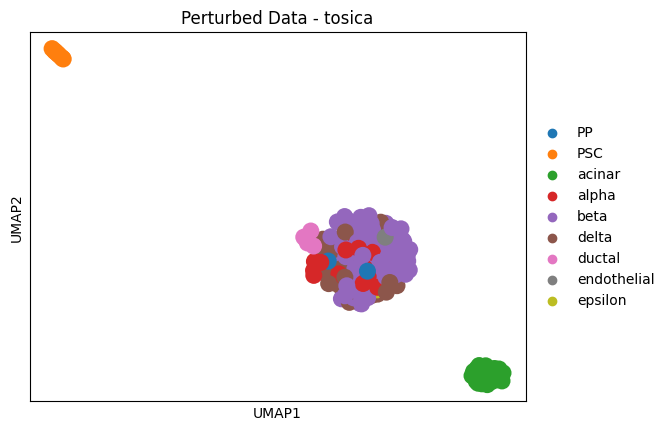

scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - WARNING - The input data seems to be already log1p transformed. Set `log1p=False` to avoid double log1p transform.
scGPT - INFO - Binning data ...


c:\Users\gaiacronus\.conda\envs\demo8\lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 200 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

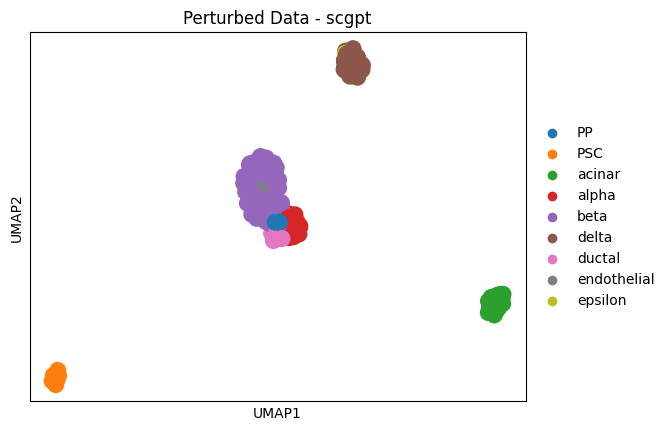

Perturbation completed. Save the perturbed data as needed.


In [43]:
import torch
import scanpy as sc
import numpy as np
import pandas as pd
import TOSICA
from scgpt.model import TransformerModel
from scgpt.tokenizer import tokenize_and_pad_batch, GeneVocab
from scgpt.preprocess import Preprocessor
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import umap
import wandb
import json
import os
from torch.utils.data import DataLoader
import warnings
from scgpt.loss import masked_mse_loss

# Unified configuration
config = {
    'project': 'combined_cell_annotation',
    'models': ['scgpt'],  # Select models to run
    'task': 'perturbation',  # Options: 'annotation' or 'perturbation'
    'data_paths': {
        'ref': 'C:/Users/gaiacronus/Downloads/work/combine/modelresults/truncated_train.h5ad',
        'query': 'C:/Users/gaiacronus/Downloads/work/combine/modelresults/truncated_test.h5ad'
    },
    'tosica_params': {
        'epochs': 1,
        'gmt_path': 'human_gobp',
        'label_name': 'Celltype',
    },
    'scgpt_params': {
        'seed': 0,
        'epochs': 1,
        'batch_size': 32,
        'lr': 1e-4,
        'mask_ratio': 0.1,
        'n_bins': 51,
        'pretrained_path': 'C:/Users/gaiacronus/Downloads/work/combine/scGPT_human/best_model.pt',
        'n_layers_cls': 3
    },
    'output_dir': 'C:/Users/gaiacronus/Downloads/work/combine/results/new_results'
}
def visualize_perturbation(adata, model_name):
    """Visualize perturbed data using UMAP"""
    sc.pp.neighbors(adata, n_neighbors=15)
    sc.tl.umap(adata)
    
    plt.figure(figsize=(8, 6))
    sc.pl.umap(adata, color='Celltype', show=False)
    plt.title(f'Perturbed Data - {model_name}')
    plt.show()
def perturb_data(adata, model_type):
    """Apply perturbations to the dataset."""
    if model_type == 'tosica':
        noise_factor = 0.05
        adata.X = adata.X + noise_factor * np.random.normal(size=adata.X.shape)
        visualize_perturbation(adata, model_type)
        return adata
    
    elif model_type == 'scgpt':
        mask_ratio = config['scgpt_params']['mask_ratio']
        mask_indices = np.random.rand(*adata.layers['X_binned'].shape) < mask_ratio
        adata.layers['X_binned'][mask_indices] = -1
        visualize_perturbation(adata, model_type)
        return adata

def load_and_preprocess(model_type, path):
    """Model-specific data loading and preprocessing"""
    adata = sc.read(path)
    
    if model_type == 'tosica':
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        adata = adata[:, adata.var_names]
        adata.obs['Celltype'] = adata.obs['Celltype'].astype('category')
        if config['task'] == 'perturbation':
            return perturb_data(adata, 'tosica')
        return adata
    
    elif model_type == 'scgpt':
        preprocessor = Preprocessor(
            use_key="X",
            filter_gene_by_counts=False,
            normalize_total=1e4,
            log1p=True,
            binning=config['scgpt_params']['n_bins']
        )
        preprocessor(adata)
        adata.obs['Celltype'] = adata.obs['Celltype'].astype('category')
        if config['task'] == 'perturbation':
            return perturb_data(adata, 'scgpt')
        return adata

def tosica_annotation(train_data, query_data):
    """TOSICA cell type annotation pipeline"""
    TOSICA.train(train_data, gmt_path=config['tosica_params']['gmt_path'], label_name=config['tosica_params']['label_name'], epochs=config['tosica_params']['epochs'], project=config['project'])
    model_path = f"./{config['project']}/model-0.pth"
    annotated_data = TOSICA.pre(query_data, model_weight_path=model_path, project=config['project'])
    return annotated_data.obs['Prediction'].values

def scgpt_annotation(train_data, query_data):
    """scGPT cell type annotation pipeline"""
    vocab_dir = os.path.dirname(config['scgpt_params']['pretrained_path'])
    vocab_path = os.path.join(vocab_dir, "vocab.json")
    with open(vocab_path, 'r') as file:
        token2idx = json.load(file)
    vocab = GeneVocab.from_dict(token2idx)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TransformerModel(ntoken=len(vocab), d_model=512, nhead=8, d_hid=512, nlayers=12, nlayers_cls=config['scgpt_params']['n_layers_cls'], n_cls=10, pad_token="<pad>", vocab=vocab, dropout=0.2).to(device)
    pretrained_dict = torch.load(config['scgpt_params']['pretrained_path'], map_location=device)
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict, strict=False)
    query_loader = prepare_scgpt_batches(query_data,vocab)
    predictions = []
    with torch.no_grad():
            for batch in query_loader:
                inputs = batch['gene_ids'].to(device)
                values = batch['values'].to(device)
                src_key_padding_mask = inputs.eq(vocab["<pad>"])  # Generate mask for padded tokens
                outputs = model(inputs, values, src_key_padding_mask=src_key_padding_mask)
                
                predictions.extend(outputs["mlm_output"].argmax(dim=1).cpu().numpy())
    return predictions
class SeqDataset(torch.utils.data.Dataset):
    """Helper class for scGPT data loading"""
    def __init__(self, tokenized_data, adata):
        self.data = tokenized_data
        self.celltype = adata.obs["Celltype"].tolist()
        self.celltype = np.array(self.celltype)

    def __len__(self):
        return len(self.data['genes'])

    def __getitem__(self, idx):
        item = {
            'gene_ids': self.data['genes'][idx],
            'values': self.data['values'][idx],
            'celltype_labels': self.celltype[idx]
        }
        return item
def prepare_scgpt_batches(adata,vocab):
    """Convert AnnData object to DataLoader-friendly format"""
    gene_ids = np.array([vocab[gene] for gene in adata.var_names], dtype=int)
    max_len = 3001  # Adjust based on model requirements
    tokenized = tokenize_and_pad_batch(
        adata.layers['X_binned'],
        gene_ids,
        max_len=max_len,
        vocab=vocab,
        pad_token="<pad>",
        pad_value=vocab["<pad>"],
        append_cls=True,
        include_zero_gene=False,
        cls_token="<cls>",
        return_pt=True
    )
    return DataLoader(SeqDataset(tokenized, adata), batch_size=config['scgpt_params']['batch_size'])

# Replace this in scgpt_annotation()




def visualize_results(adata, predictions, model_name):
    """Visualization for both models"""
    sc.pp.neighbors(adata, n_neighbors=15)
    sc.tl.umap(adata)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # True labels
    sc.pl.umap(adata, color='Celltype', ax=ax1, show=False)
    ax1.set_title(f'True Cell Types - {model_name}')
    
    # Predicted labels
    adata.obs['predicted'] = pd.Categorical([
    adata.obs['Celltype'].cat.categories[i] if isinstance(i, (int, np.integer)) and i < len(adata.obs['Celltype'].cat.categories) else 'Unknown'
    for i in predictions])
    sc.pl.umap(adata, color='predicted', ax=ax2, show=False)
    ax2.set_title(f'Predicted Cell Types - {model_name}')
    plt.show()

def run_annotation():
    """Runs annotation task if selected in config."""
    print("Loading and preprocessing data for annotation...")
    tosica_ref = load_and_preprocess('tosica', config['data_paths']['ref'])
    tosica_query = load_and_preprocess('tosica', config['data_paths']['query'])
    scgpt_ref = load_and_preprocess('scgpt', config['data_paths']['ref'])
    scgpt_query = load_and_preprocess('scgpt', config['data_paths']['query'])
    
    results = {}
    
    if 'tosica' in config['models']:
        print("Running TOSICA annotation...")
        tosica_pred = tosica_annotation(tosica_ref, tosica_query)
        tosica_pred = pd.Categorical(list(map(str, tosica_pred)), categories=tosica_query.obs['Celltype'].cat.categories).codes
        accuracy = accuracy_score(tosica_query.obs['Celltype'].cat.codes, tosica_pred)
        f1 = f1_score(tosica_query.obs['Celltype'].cat.codes, tosica_pred, average='weighted')
        results['tosica'] = {'Accuracy': accuracy, 'F1 Score': f1}
        visualize_results(tosica_query, tosica_pred, 'TOSICA')
        print("Running TOSICA annotation...")
        tosica_pred = tosica_annotation(tosica_ref, tosica_query)
        results['tosica'] = {'Accuracy': accuracy, 'F1 Score': f1}
        visualize_results(tosica_query, tosica_pred, 'TOSICA')
        print("\nRunning TOSICA annotation...")
        tosica_pred = tosica_annotation(tosica_ref, tosica_query)
        tosica_pred = pd.Categorical(tosica_pred, categories=tosica_query.obs['Celltype'].cat.categories).codes
        results['tosica'] = {'Accuracy': accuracy_score(tosica_query.obs['Celltype'].cat.codes, tosica_pred), 
                         'F1 Score': f1_score(tosica_query.obs['Celltype'].cat.codes, tosica_pred, average='weighted')}
    
    if 'scgpt' in config['models']:
        print("Running scGPT annotation...")
        scgpt_pred = scgpt_annotation(scgpt_ref, scgpt_query)
        scgpt_pred = pd.Categorical(list(scgpt_pred), categories=scgpt_query.obs['Celltype'].cat.categories).codes
        accuracy = accuracy_score(scgpt_query.obs['Celltype'].cat.codes, scgpt_pred)
        f1 = f1_score(scgpt_query.obs['Celltype'].cat.codes, scgpt_pred, average='weighted')
        results['scgpt'] = {'Accuracy': accuracy, 'F1 Score': f1}
        visualize_results(scgpt_query, scgpt_pred, 'scGPT')
        print("Running scGPT annotation...")
        scgpt_pred = scgpt_annotation(scgpt_ref, scgpt_query)
        results['scgpt'] = {'Accuracy': accuracy, 'F1 Score': f1}
        visualize_results(scgpt_query, scgpt_pred, 'scGPT')
        print("\nRunning scGPT annotation...")
        scgpt_pred = scgpt_annotation(scgpt_ref, scgpt_query)
        results['scgpt'] = {'Accuracy': accuracy_score(scgpt_query.obs['Celltype'].cat.codes, scgpt_pred), 
                         'F1 Score': f1_score(scgpt_query.obs['Celltype'].cat.codes, scgpt_pred, average='weighted')}
    
    pd.DataFrame(results).to_csv(f"{config['output_dir']}/annotation_results.csv")
    print("Annotation Results:", results)
    
    # Plot accuracy and F1 scores
    models = list(results.keys())
    accuracies = [results[m]['Accuracy'] for m in models]
    f1_scores = [results[m]['F1 Score'] for m in models]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(models))
    width = 0.35
    
    ax.bar(x - width/2, accuracies, width, label='Accuracy')
    ax.bar(x + width/2, f1_scores, width, label='F1 Score')
    
    ax.set_xlabel('Models')
    ax.set_ylabel('Scores')
    ax.set_title('Model Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    
    plt.show()
    
    # Convert results to DataFrame and save as Excel file
    results_df = pd.DataFrame.from_dict(results, orient='index')
    results_df.columns = ['Accuracy', 'F1 Score']
    excel_path = os.path.join(config['output_dir'], 'annotation_results.xlsx')
    results_df.to_excel(excel_path, index=True)
    print(f"Results saved to {excel_path}")
    

def run_pipeline():
    """Main execution pipeline"""
    wandb.init(project=config['project'])
    if config['task'] == 'perturbation':
        print("Running perturbation only...")
        load_and_preprocess('tosica', config['data_paths']['ref'])
        load_and_preprocess('scgpt', config['data_paths']['ref'])
        print("Perturbation completed. Save the perturbed data as needed.")
    elif config['task'] == 'annotation':
        run_annotation()

if __name__ == "__main__":
    run_pipeline()
